# Análisis de regresión — Dióxido de nitrógeno (NO₂) en el estado de Washington, 2022–2023

**Curso:** Proyectos de Ingeniería 1 — Guía 1: Regresión
**Autor:** Ruben Andre Cabrera Cermeño — Universidad Peruana Cayetano Heredia
**Fuente de datos:** US EPA, *Outdoor Air Quality Data — Download Daily Data*
**Indicador:** `Daily Max 1-hour NO2 Concentration` (ppb)

## 1. Configuración e importación de librerías

In [1]:
import os
import glob

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 120)

## 2. Carga de datos

Se emplean dos archivos descargados de la EPA, uno por año (2022 y 2023), con los
mismos filtros: contaminante NO₂, estado de Washington, todas las estaciones.
La celda busca los CSV en el entorno y, si no los encuentra, abre el diálogo de
subida de Colab.

In [2]:
CONC = "Daily Max 1-hour NO2 Concentration"

def localizar_csv():
    """Devuelve la lista de CSV de la EPA presentes; si no hay, los solicita en Colab."""
    patrones = ["ad_viz_plotval_data*.csv", "datos/ad_viz_plotval_data*.csv",
                "/content/ad_viz_plotval_data*.csv"]
    for patron in patrones:
        encontrados = sorted(glob.glob(patron))
        if encontrados:
            return encontrados

    sueltos = [f for f in glob.glob("*.csv") + glob.glob("/content/*.csv")
               if "sample_data" not in f]
    if sueltos:
        print("Se usarán los CSV encontrados:", sueltos)
        return sorted(sueltos)

    try:
        from google.colab import files
        print("Sube los dos archivos CSV descargados de la EPA (2022 y 2023):")
        subidos = files.upload()
        return sorted(subidos.keys())
    except ImportError:
        raise FileNotFoundError("No se encontraron los CSV de la EPA en el entorno.")

archivos = localizar_csv()
print("Archivos:", archivos)

df = pd.concat([pd.read_csv(f) for f in archivos], ignore_index=True)
df.columns = df.columns.str.strip()

assert CONC in df.columns, f"Falta la columna '{CONC}'. Columnas: {list(df.columns)}"

print("Dimensiones:", df.shape)
print("Columnas:", list(df.columns))
df.head()

Archivos: ['ad_viz_plotval_data-2.csv', 'ad_viz_plotval_data.csv']
Dimensiones: (2098, 21)
Columnas: ['Date', 'Source', 'Site ID', 'POC', 'Daily Max 1-hour NO2 Concentration', 'Units', 'Daily AQI Value', 'Local Site Name', 'Daily Obs Count', 'Percent Complete', 'AQS Parameter Code', 'AQS Parameter Description', 'Method Code', 'CBSA Code', 'CBSA Name', 'State FIPS Code', 'State', 'County FIPS Code', 'County', 'Site Latitude', 'Site Longitude']


,Date,Source,Site ID,POC,Daily Max 1-hour NO2 Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,...,AQS Parameter Description,Method Code,CBSA Code,CBSA Name,State FIPS Code,State,County FIPS Code,County,Site Latitude,Site Longitude
0,01/01/2022,AQS,530330030,1,23.9,ppb,22,Seattle-10th & Weller,23,96.0,...,Nitrogen dioxide (NO2),599,42660,"Seattle-Tacoma-Bellevue, WA",53,Washington,33,King,47.597222,-122.319722
1,01/02/2022,AQS,530330030,1,32.5,ppb,30,Seattle-10th & Weller,23,96.0,...,Nitrogen dioxide (NO2),599,42660,"Seattle-Tacoma-Bellevue, WA",53,Washington,33,King,47.597222,-122.319722
2,01/03/2022,AQS,530330030,1,28.9,ppb,26,Seattle-10th & Weller,23,96.0,...,Nitrogen dioxide (NO2),599,42660,"Seattle-Tacoma-Bellevue, WA",53,Washington,33,King,47.597222,-122.319722
3,01/04/2022,AQS,530330030,1,30.6,ppb,28,Seattle-10th & Weller,22,92.0,...,Nitrogen dioxide (NO2),599,42660,"Seattle-Tacoma-Bellevue, WA",53,Washington,33,King,47.597222,-122.319722
4,01/05/2022,AQS,530330030,1,23.3,ppb,22,Seattle-10th & Weller,23,96.0,...,Nitrogen dioxide (NO2),599,42660,"Seattle-Tacoma-Bellevue, WA",53,Washington,33,King,47.597222,-122.319722


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2098 entries, 0 to 2097
Data columns (total 21 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Date                                2098 non-null   object 
 1   Source                              2098 non-null   object 
 2   Site ID                             2098 non-null   int64  
 3   POC                                 2098 non-null   int64  
 4   Daily Max 1-hour NO2 Concentration  2098 non-null   float64
 5   Units                               2098 non-null   object 
 6   Daily AQI Value                     2098 non-null   int64  
 7   Local Site Name                     2098 non-null   object 
 8   Daily Obs Count                     2098 non-null   int64  
 9   Percent Complete                    2098 non-null   float64
 10  AQS Parameter Code                  2098 non-null   int64  
 11  AQS Parameter Description           2098 no

## 3. Preprocesamiento

1. Conversión de `Date` a tipo fecha y eliminación de registros nulos.
2. Revisión de la cobertura temporal de cada estación.
3. Construcción de una serie diaria única promediando las estaciones.

In [4]:
df["Fecha"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")
df = df.dropna(subset=["Fecha", CONC])

print("Años presentes:", sorted(df["Fecha"].dt.year.unique()))
print("Unidades:", df["Units"].unique())
print("\nCobertura por estación:")
df.groupby("Local Site Name")["Fecha"].agg(["min", "max", "count"])

Años presentes: [np.int32(2022), np.int32(2023)]
Unidades: ['ppb']

Cobertura por estación:


,min,max,count
Local Site Name,,,
SEATTLE - BEACON HILL,2022-01-01,2023-12-31,710
Seattle-10th & Weller,2022-01-01,2023-12-30,690
Tacoma-S 36th St,2022-01-01,2023-12-31,698


In [5]:
serie = (df.groupby("Fecha")[[CONC, "Daily AQI Value"]]
           .mean()
           .rename(columns={CONC: "NO2", "Daily AQI Value": "AQI"})
           .reset_index()
           .sort_values("Fecha")
           .reset_index(drop=True))

serie["t"]     = (serie["Fecha"] - serie["Fecha"].min()).dt.days
serie["mes"]   = serie["Fecha"].dt.month
serie["doy"]   = serie["Fecha"].dt.dayofyear
serie["anio"]  = serie["Fecha"].dt.year

print("Serie diaria:", serie.shape)
serie.describe().round(4)

Serie diaria: (730, 7)


,Fecha,NO2,AQI,t,mes,doy,anio
count,730,730.0000,730.0000,730.0000,730.0000,730.0000,730.0000
mean,2022-12-31 12:00:00,24.1410,22.3550,364.5000,6.5260,183.0000,2022.5000
min,2022-01-01 00:00:00,7.5000,6.6667,0.0000,1.0000,1.0000,2022.0000
25%,2022-07-02 06:00:00,19.0083,17.6667,182.2500,4.0000,92.0000,2022.0000
50%,2022-12-31 12:00:00,23.4167,21.6667,364.5000,7.0000,183.0000,2022.5000
75%,2023-07-01 18:00:00,28.3917,26.3333,546.7500,10.0000,274.0000,2023.0000
max,2023-12-31 00:00:00,63.6667,61.0000,729.0000,12.0000,365.0000,2023.0000
std,NaN,7.6710,7.2678,210.8771,3.4502,105.4383,0.5003


## 4. Análisis exploratorio

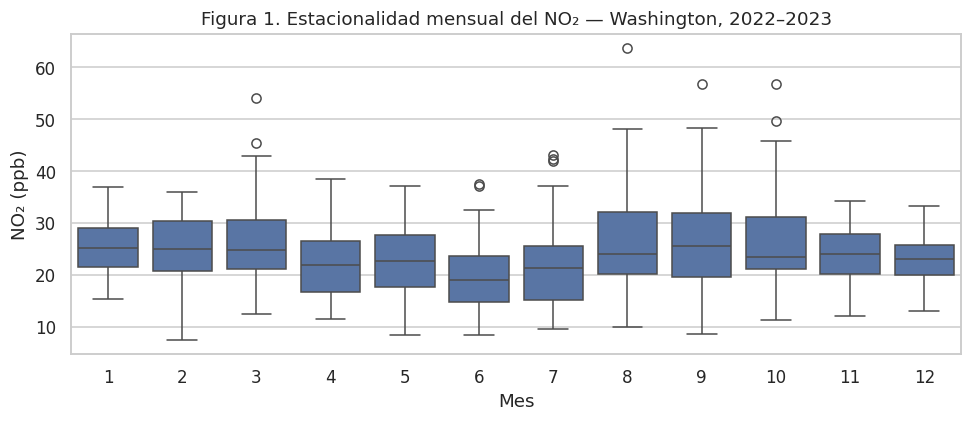

,mean,median,std
mes,,,
1,25.1339,25.2500,4.9189
2,24.8363,25.0833,6.5240
3,26.2255,24.8000,7.9220
4,22.3050,21.9750,7.0488
5,22.9540,22.7000,6.5544
6,19.6136,18.9667,6.6004
7,21.7409,21.3167,8.3825
8,26.3446,24.1083,9.2036
9,26.7622,25.5000,9.7880


In [6]:
plt.figure(figsize=(9, 4))
sns.boxplot(x="mes", y="NO2", data=serie, color="#4c72b0")
plt.title("Figura 1. Estacionalidad mensual del NO₂ — Washington, 2022–2023")
plt.xlabel("Mes"); plt.ylabel("NO₂ (ppb)")
plt.tight_layout(); plt.savefig("fig1_estacionalidad.png", bbox_inches="tight"); plt.show()

serie.groupby("mes")["NO2"].agg(["mean", "median", "std"]).round(4)

In [7]:
# Estadísticas por estación de monitoreo (sin gráfico: solo 3 estaciones)
por_sitio = (df.groupby("Local Site Name")[CONC]
               .agg(["mean", "std", "max", "count"])
               .sort_values("mean", ascending=False)
               .round(3))
print(por_sitio)

# Comparación entre años
print("\nMedia anual de NO₂:")
print(serie.groupby("anio")["NO2"].agg(["mean", "std", "count"]).round(4))

                         mean    std   max  count
Local Site Name                                  
Seattle-10th & Weller  28.036  9.206  78.5    690
Tacoma-S 36th St       22.807  7.479  63.2    698
SEATTLE - BEACON HILL  21.498  9.435  69.2    710

Media anual de NO₂:
         mean     std  count
anio                        
2022  24.6881  8.0255    365
2023  23.5938  7.2692    365


In [8]:
t_stat, p_val = stats.ttest_ind(serie.loc[serie["anio"] == 2022, "NO2"],
                                serie.loc[serie["anio"] == 2023, "NO2"],
                                equal_var=False)
print(f"Prueba t de Welch (2022 vs 2023): t = {t_stat:.3f}, p = {p_val:.4f}")
print("Correlación de Pearson NO₂–AQI:", round(serie["NO2"].corr(serie["AQI"]), 4))

Prueba t de Welch (2022 vs 2023): t = 1.931, p = 0.0539
Correlación de Pearson NO₂–AQI: 0.9994


## 5. Modelo M1 — Regresión lineal simple

Especificación: `NO2 = b0 + b1 * t + e`, donde `t` son los días transcurridos
desde el 1 de enero de 2022.

Intercepto : 24.9076 ppb
Pendiente  : -0.002103 ppb/día  ->  -0.7677 ppb/año
R²         : 0.0033
RMSE       : 7.6529 ppb
MAE        : 5.8361 ppb


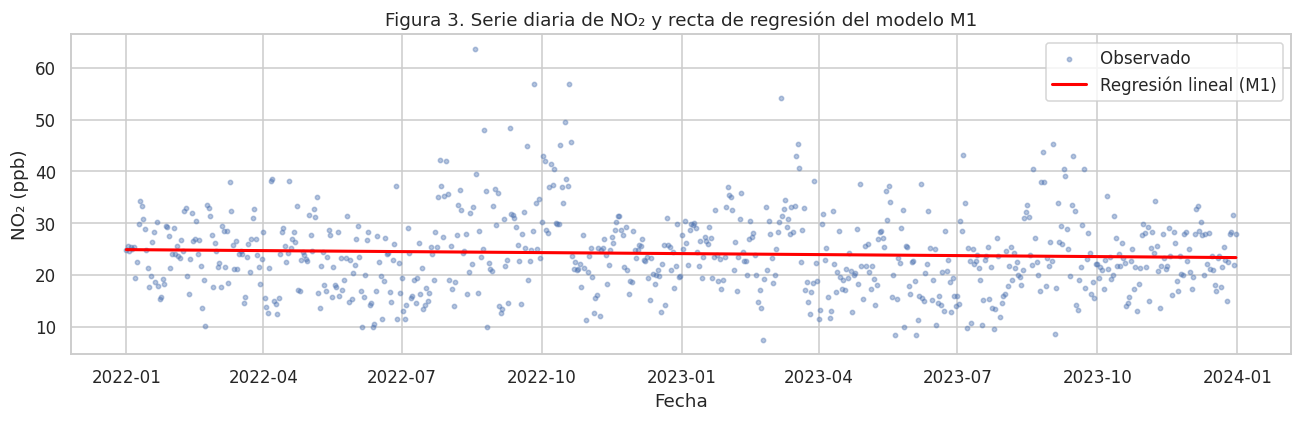

In [9]:
X = serie[["t"]]
y = serie["NO2"]

m1_sk = LinearRegression().fit(X, y)
pred1 = m1_sk.predict(X)

print(f"Intercepto : {m1_sk.intercept_:.4f} ppb")
print(f"Pendiente  : {m1_sk.coef_[0]:.6f} ppb/día  ->  {m1_sk.coef_[0]*365:.4f} ppb/año")
print(f"R²         : {r2_score(y, pred1):.4f}")
print(f"RMSE       : {np.sqrt(mean_squared_error(y, pred1)):.4f} ppb")
print(f"MAE        : {mean_absolute_error(y, pred1):.4f} ppb")

plt.figure(figsize=(12, 4))
plt.scatter(serie["Fecha"], y, s=8, alpha=.4, label="Observado")
plt.plot(serie["Fecha"], pred1, color="red", lw=2, label="Regresión lineal (M1)")
plt.title("Figura 3. Serie diaria de NO₂ y recta de regresión del modelo M1")
plt.xlabel("Fecha"); plt.ylabel("NO₂ (ppb)"); plt.legend()
plt.tight_layout(); plt.savefig("fig3_regresion_simple.png", bbox_inches="tight"); plt.show()

In [10]:
m1 = sm.OLS(y, sm.add_constant(X)).fit()
print(m1.summary())

                            OLS Regression Results                            
Dep. Variable:                    NO2   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     2.442
Date:                Thu, 17 Sep 2026   Prob (F-statistic):              0.119
Time:                        21:14:54   Log-Likelihood:                -2521.4
No. Observations:                 730   AIC:                             5047.
Df Residuals:                     728   BIC:                             5056.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         24.9076      0.567     43.953      0.0

## 6. Modelo M2 — Regresión lineal múltiple

Se incorporan la estacionalidad anual mediante armónicos y la persistencia
mediante el valor rezagado un día.

In [11]:
serie["sin_doy"] = np.sin(2*np.pi*serie["doy"]/365)
serie["cos_doy"] = np.cos(2*np.pi*serie["doy"]/365)
serie["lag1"]    = serie["NO2"].shift(1)

d = serie.dropna().reset_index(drop=True)
d["log_NO2"]  = np.log(d["NO2"])
d["log_lag1"] = np.log(d["lag1"])

feats2 = ["t", "sin_doy", "cos_doy", "lag1"]

m2 = sm.OLS(d["NO2"], sm.add_constant(d[feats2])).fit()
print(m2.summary())
print("\nDurbin-Watson:", round(sm.stats.durbin_watson(m2.resid), 3))

                            OLS Regression Results                            
Dep. Variable:                    NO2   R-squared:                       0.199
Model:                            OLS   Adj. R-squared:                  0.195
Method:                 Least Squares   F-statistic:                     45.00
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           9.03e-34
Time:                        21:14:56   Log-Likelihood:                -2438.8
No. Observations:                 729   AIC:                             4888.
Df Residuals:                     724   BIC:                             4910.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         15.2260      1.030     14.787      0.0

### 6.1 Validación con partición temporal

Partición cronológica, no aleatoria, para no filtrar información futura hacia
el entrenamiento:

- Entrenamiento: enero de 2022 – junio de 2023
- Prueba: julio – diciembre de 2023

Entrenamiento: 545 días | Prueba: 184 días

M1 (solo tendencia)          R² = -0.0022 | RMSE = 6.9107 | MAE = 5.2311
M2 (múltiple, niveles)       R² =  0.0671 | RMSE = 6.6678 | MAE = 5.0591


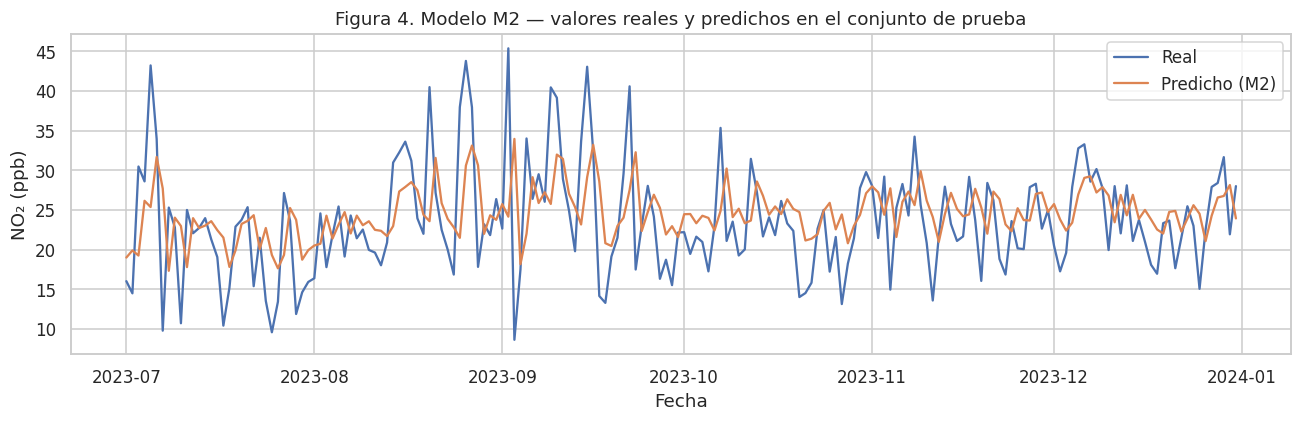

In [12]:
corte = d["Fecha"] < "2023-07-01"
y_te  = d.loc[~corte, "NO2"]

def evaluar(feats, dep="NO2", log=False, etiqueta=""):
    mod = LinearRegression().fit(d.loc[corte, feats], d.loc[corte, dep])
    p = mod.predict(d.loc[~corte, feats])
    if log:
        p = np.exp(p)
    r2, rmse, mae = (r2_score(y_te, p),
                     np.sqrt(mean_squared_error(y_te, p)),
                     mean_absolute_error(y_te, p))
    print(f"{etiqueta:<28} R² = {r2:7.4f} | RMSE = {rmse:.4f} | MAE = {mae:.4f}")
    return mod, p, (r2, rmse, mae)

print(f"Entrenamiento: {corte.sum()} días | Prueba: {(~corte).sum()} días\n")
_,      p1, res1 = evaluar(["t"],  etiqueta="M1 (solo tendencia)")
m2_sk,  p2, res2 = evaluar(feats2, etiqueta="M2 (múltiple, niveles)")

plt.figure(figsize=(12, 4))
plt.plot(d.loc[~corte, "Fecha"], y_te, label="Real", lw=1.5)
plt.plot(d.loc[~corte, "Fecha"], p2, label="Predicho (M2)", lw=1.5)
plt.title("Figura 4. Modelo M2 — valores reales y predichos en el conjunto de prueba")
plt.xlabel("Fecha"); plt.ylabel("NO₂ (ppb)"); plt.legend()
plt.tight_layout(); plt.savefig("fig4_m2_prueba.png", bbox_inches="tight"); plt.show()

## 7. Modelo M3 — Especificación logarítmica

Se estima para corregir la asimetría de los residuos del modelo en niveles,
rezagando `ln(NO2)` para mantener la coherencia de escala.

In [13]:
feats3 = ["t", "sin_doy", "cos_doy", "log_lag1"]

m3 = sm.OLS(d["log_NO2"], sm.add_constant(d[feats3])).fit()
print(m3.summary())
print("\nDurbin-Watson:", round(sm.stats.durbin_watson(m3.resid), 3))

m3_sk, p3, res3 = evaluar(feats3, dep="log_NO2", log=True, etiqueta="M3 (log-log)")

                            OLS Regression Results                            
Dep. Variable:                log_NO2   R-squared:                       0.186
Model:                            OLS   Adj. R-squared:                  0.182
Method:                 Least Squares   F-statistic:                     41.45
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           2.61e-31
Time:                        21:15:04   Log-Likelihood:                -131.10
No. Observations:                 729   AIC:                             272.2
Df Residuals:                     724   BIC:                             295.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.9742      0.112     17.593      0.0

## 8. Pruebas estadísticas de los supuestos

In [14]:
# Normalidad de los residuos: Jarque-Bera y Shapiro-Wilk
print("NORMALIDAD DE LOS RESIDUOS")
for nombre, mod in [("M2 (niveles)", m2), ("M3 (log-log)", m3)]:
    jb, jb_p = sm.stats.jarque_bera(mod.resid)[:2]
    sw, sw_p = stats.shapiro(mod.resid)
    print(f"{nombre:<14} asimetría = {stats.skew(mod.resid):6.3f} | "
          f"curtosis = {stats.kurtosis(mod.resid):6.3f}")
    print(f"{'':<14} Jarque-Bera = {jb:8.3f} (p = {jb_p:.4f}) | "
          f"Shapiro-Wilk = {sw:.4f} (p = {sw_p:.4g})")

# Heterocedasticidad: Breusch-Pagan
print("\nHETEROCEDASTICIDAD (Breusch-Pagan)")
for nombre, mod, fts in [("M2 (niveles)", m2, feats2), ("M3 (log-log)", m3, feats3)]:
    lm, lm_p, f_st, f_p = het_breuschpagan(mod.resid, sm.add_constant(d[fts]))
    print(f"{nombre:<14} LM = {lm:7.3f} (p = {lm_p:.4f}) -> "
          f"{'se rechaza homocedasticidad' if lm_p < 0.05 else 'no se rechaza homocedasticidad'}")

# Multicolinealidad: factores de inflación de la varianza
print("\nMULTICOLINEALIDAD (VIF, modelo M2)")
Xv = sm.add_constant(d[feats2])
for i, col in enumerate(Xv.columns):
    if col == "const":
        continue
    print(f"{col:<12} VIF = {variance_inflation_factor(Xv.values, i):.3f}")

NORMALIDAD DE LOS RESIDUOS
M2 (niveles)   asimetría =  0.709 | curtosis =  2.290
               Jarque-Bera =  220.303 (p = 0.0000) | Shapiro-Wilk = 0.9690 (p = 2.654e-11)
M3 (log-log)   asimetría = -0.374 | curtosis =  0.907
               Jarque-Bera =   41.958 (p = 0.0000) | Shapiro-Wilk = 0.9874 (p = 6.65e-06)

HETEROCEDASTICIDAD (Breusch-Pagan)
M2 (niveles)   LM =  33.026 (p = 0.0000) -> se rechaza homocedasticidad
M3 (log-log)   LM =  27.118 (p = 0.0000) -> se rechaza homocedasticidad

MULTICOLINEALIDAD (VIF, modelo M2)
t            VIF = 1.196
sin_doy      VIF = 1.207
cos_doy      VIF = 1.014
lag1         VIF = 1.040


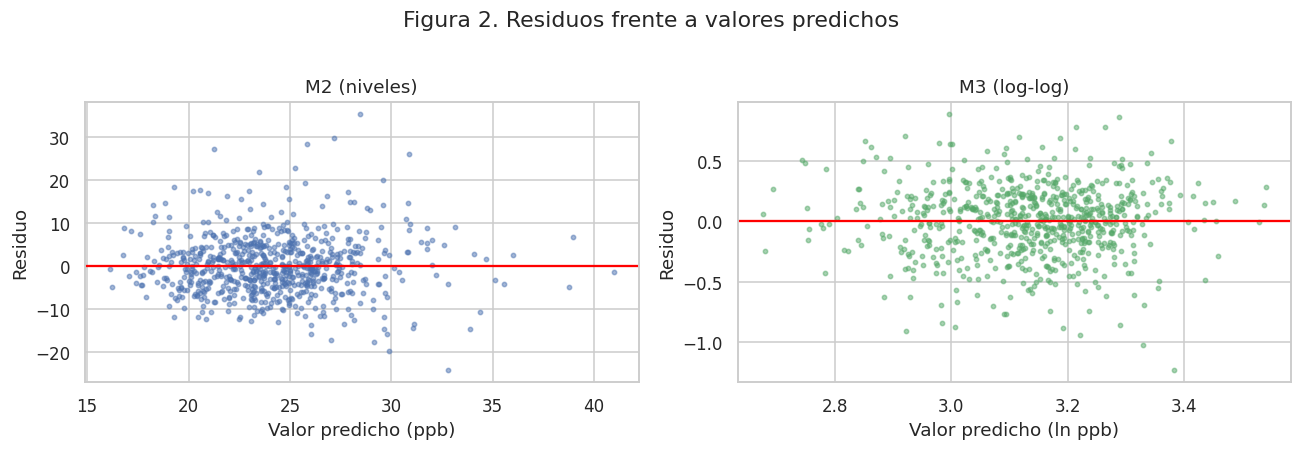

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].scatter(m2.fittedvalues, m2.resid, s=8, alpha=.5)
ax[0].axhline(0, color="red")
ax[0].set_title("M2 (niveles)")
ax[0].set_xlabel("Valor predicho (ppb)"); ax[0].set_ylabel("Residuo")

ax[1].scatter(m3.fittedvalues, m3.resid, s=8, alpha=.5, color="#55a868")
ax[1].axhline(0, color="red")
ax[1].set_title("M3 (log-log)")
ax[1].set_xlabel("Valor predicho (ln ppb)"); ax[1].set_ylabel("Residuo")

fig.suptitle("Figura 2. Residuos frente a valores predichos", y=1.02)
plt.tight_layout(); plt.savefig("fig2_residuos.png", bbox_inches="tight"); plt.show()

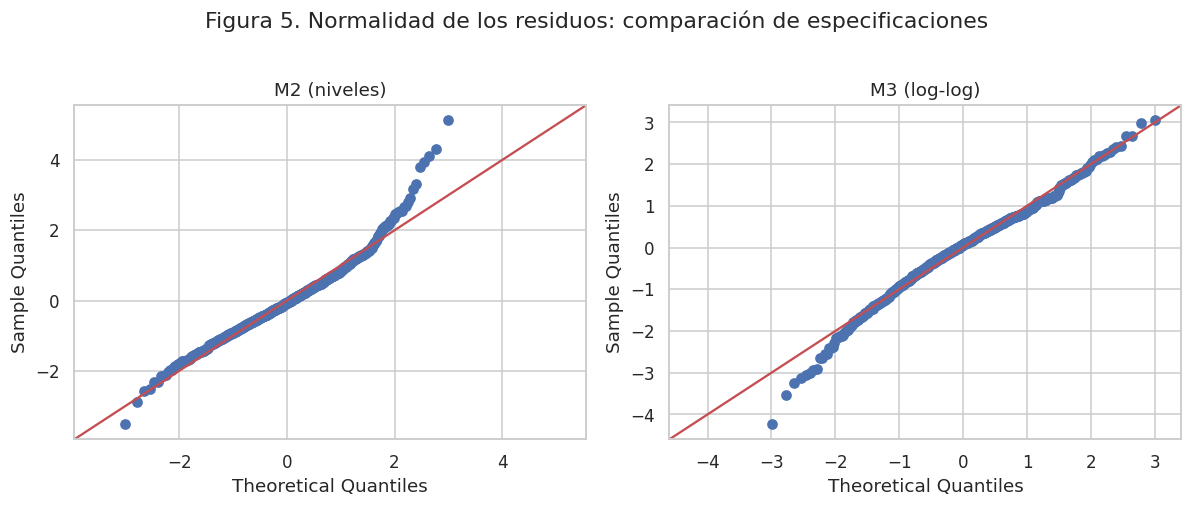

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
sm.qqplot(m2.resid, line="45", fit=True, ax=ax[0]); ax[0].set_title("M2 (niveles)")
sm.qqplot(m3.resid, line="45", fit=True, ax=ax[1]); ax[1].set_title("M3 (log-log)")
fig.suptitle("Figura 5. Normalidad de los residuos: comparación de especificaciones", y=1.02)
plt.tight_layout(); plt.savefig("fig5_qq.png", bbox_inches="tight"); plt.show()

## 9. Tabla comparativa de modelos

In [17]:
resumen = pd.DataFrame({
    "Modelo": ["M1 — Simple (t)", "M2 — Múltiple (niveles)", "M3 — Log-log"],
    "R² ajuste":   [m1.rsquared, m2.rsquared, m3.rsquared],
    "R² ajustado": [m1.rsquared_adj, m2.rsquared_adj, m3.rsquared_adj],
    "F":           [m1.fvalue, m2.fvalue, m3.fvalue],
    "p (F)":       [m1.f_pvalue, m2.f_pvalue, m3.f_pvalue],
    "Durbin-Watson": [sm.stats.durbin_watson(m1.resid),
                      sm.stats.durbin_watson(m2.resid),
                      sm.stats.durbin_watson(m3.resid)],
    "R² prueba":   [res1[0], res2[0], res3[0]],
    "RMSE prueba": [res1[1], res2[1], res3[1]],
    "MAE prueba":  [res1[2], res2[2], res3[2]],
})
resumen.round(4)

,Modelo,R² ajuste,R² ajustado,F,p (F),Durbin-Watson,R² prueba,RMSE prueba,MAE prueba
0,M1 — Simple (t),0.0033,0.0020,2.4419,0.1186,1.1406,-0.0022,6.9107,5.2311
1,M2 — Múltiple (niveles),0.1991,0.1947,45.0005,0.0000,1.9833,0.0671,6.6678,5.0591
2,M3 — Log-log,0.1863,0.1818,41.4511,0.0000,1.9806,0.0900,6.5852,4.9004


## 10. Conclusiones

Las conclusiones detalladas, con la interpretación de cada coeficiente y la
discusión de limitaciones, se encuentran en el informe `README.md` del
repositorio.